**I chose the Boston Housing Dataset. It’s small, easy to visualize, clean, and widely used in linear regression tutorials.**
First, we load the csv file using numpy library.

In [2]:
import numpy as np

# Load csv
data = np.loadtxt('BostonHousing.csv', delimiter=',', skiprows=1)

# Separate features and target
X = data[:, :-1]  # 13 features
y = data[:, -1]   # target: Median house value

Then we split data into training and test sets with a scale of 80% and 20%.

In [3]:
# Shuffle the dataset
np.random.seed(42)
indices = np.random.permutation(X.shape[0])

# 80-20 split
split_index = int(0.8 * X.shape[0])
train_idx, test_idx = indices[:split_index], indices[split_index:]

X_train, y_train = X[train_idx], y[train_idx]
X_test, y_test = X[test_idx], y[test_idx]

We choose polynomial basis functions (graded by degree *d*). For multivariate polynomial expansion (i.e., cross terms), we'd need more complex logic. But for now, we can do element-wise powers for simplicity.

In [4]:
def polynomial_basis(X, degree):
    # Add bias term (x^0)
    X_poly = np.ones((X.shape[0], 1))
    for d in range(1, degree + 1):
        X_poly = np.hstack((X_poly, X ** d))
    return X_poly

In [5]:
def train_offline(X, y):
    # Closed-form solution: w = (X^T X)^-1 X^T y
    XTX = X.T @ X
    XTy = X.T @ y
    w = np.linalg.pinv(XTX) @ XTy
    return w

In [6]:
def rmsd(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred) ** 2))

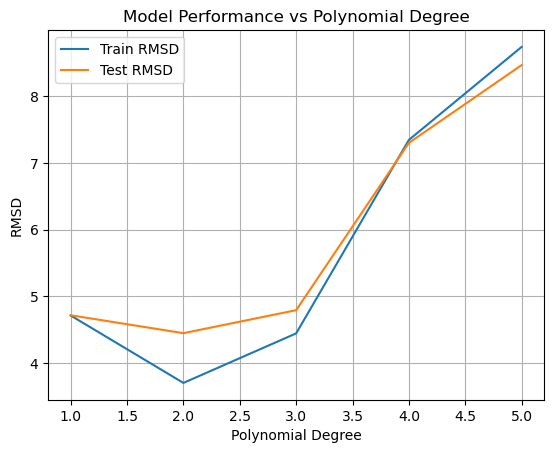

In [7]:
import matplotlib.pyplot as plt

degrees = range(1, 6)
train_rmsd = []
test_rmsd = []

for d in degrees:
    X_train_poly = polynomial_basis(X_train, d)
    X_test_poly = polynomial_basis(X_test, d)

    w = train_offline(X_train_poly, y_train)
    
    y_train_pred = X_train_poly @ w
    y_test_pred = X_test_poly @ w
    
    train_rmsd.append(rmsd(y_train, y_train_pred))
    test_rmsd.append(rmsd(y_test, y_test_pred))

plt.plot(degrees, train_rmsd, label='Train RMSD')
plt.plot(degrees, test_rmsd, label='Test RMSD')
plt.xlabel('Polynomial Degree')
plt.ylabel('RMSD')
plt.legend()
plt.grid(True)
plt.title('Model Performance vs Polynomial Degree')
plt.show()